# 📰 Economic Times — Banking News Scraper
### Anti-blocking edition with cloudscraper + session rotation + human-like delays

**Input:** A list of Economic Times article URLs  
**Output:** Clean CSV with headline, date, full article text, and bank ticker label  

**Anti-blocking features:**
- Random User-Agent rotation
- `cloudscraper` for Cloudflare bypass (fallback)
- Session refresh every N requests
- Human-like random delays between requests
- Retry logic with exponential backoff
- Referer spoofing

---
## 📦 Section 1 — Install & Imports

In [1]:
%pip install requests beautifulsoup4 cloudscraper pandas tqdm lxml

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install tqdm

import requests
import cloudscraper
import random
import time
import re
import logging
import json
from datetime import datetime
from bs4 import BeautifulSoup
import pandas as pd
from tqdm import tqdm

# ─── Logger ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s  %(message)s',
    datefmt='%H:%M:%S',
)
logger = logging.getLogger('ET_Scraper')

print('Libraries loaded.')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries loaded.


---
## ⚙️ Section 2 — Configuration

In [3]:
# ─── Output ───────────────────────────────────────────────────────────────────
OUTPUT_CSV         = 'et_banking_news.csv'
SESSION_REFRESH_N  = 8      # refresh session every N requests
MAX_RETRIES        = 3      # retry failed URLs up to 3 times
REQUEST_TIMEOUT    = 12     # seconds

# ─── Delay ranges (seconds) — mimic human reading/browsing pace ──────────────
DELAY_BETWEEN_ARTICLES = (2.5, 5.5)   # normal delay between articles
DELAY_AFTER_ERROR      = (8.0, 15.0)  # longer pause after any error
DELAY_AFTER_REFRESH    = (3.0, 6.0)   # pause after session refresh

# ─── User-Agent pool ─────────────────────────────────────────────────────────
USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/121.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/119.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:122.0) Gecko/20100101 Firefox/122.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 13_1) AppleWebKit/605.1.15 Version/16.1 Safari/605.1.15",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/122.0.0.0 Safari/537.36 Edg/122.0.0.0",
]

# ─── Referer pool (rotate to look like organic ET traffic) ───────────────────
REFERERS = [
    "https://www.google.com/",
    "https://economictimes.indiatimes.com/",
    "https://economictimes.indiatimes.com/markets/stocks/news",
    "https://economictimes.indiatimes.com/industry/banking/finance",
    "https://www.moneycontrol.com/",
    "https://www.google.co.in/search?q=HDFC+Bank+news",
]

# ─── Bank keyword → ticker mapping ───────────────────────────────────────────
BANK_KEYWORDS = {
    'HDFCBANK':   ['hdfc bank', 'hdfcbank', 'hdfc ltd'],
    'ICICIBANK':  ['icici bank', 'icicibank'],
    'SBIN':       ['state bank of india', 'sbi', 'state bank'],
    'AXISBANK':   ['axis bank', 'axisbank'],
    'KOTAKBANK':  ['kotak bank', 'kotak mahindra', 'kotakbank'],
    'INDUSINDBK': ['indusind bank', 'indusind'],
}

# Macro/sector keywords → tag as SECTOR (affects all banks)
MACRO_KEYWORDS = [
    'reserve bank of india', 'rbi', 'repo rate', 'monetary policy',
    'rate hike', 'rate cut', 'mpc meeting', 'credit growth',
    'banking sector', 'indian banks', 'npa', 'non-performing',
    'net interest margin', 'nim', 'capital adequacy',
    'federal reserve', 'fed rate', 'interest rate',
]

print('Configuration loaded.')

Configuration loaded.


---
## 🔒 Section 3 — Session & Anti-blocking Setup

In [4]:
def get_random_headers() -> dict:
    """Build a realistic browser header set with random UA and referer."""
    return {
        'User-Agent':       random.choice(USER_AGENTS),
        'Accept':           'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
        'Accept-Language':  'en-IN,en;q=0.9,hi;q=0.8',
        'Accept-Encoding':  'gzip, deflate, br',
        'Referer':          random.choice(REFERERS),
        'DNT':              '1',
        'Connection':       'keep-alive',
        'Upgrade-Insecure-Requests': '1',
        'Sec-Fetch-Dest':   'document',
        'Sec-Fetch-Mode':   'navigate',
        'Sec-Fetch-Site':   'same-origin',
        'Cache-Control':    'max-age=0',
    }


def refresh_session() -> requests.Session:
    """Create a fresh requests session with randomised headers."""
    s = requests.Session()
    s.headers.update(get_random_headers())
    logger.info('Session refreshed.')
    return s


def build_cloudscraper() -> cloudscraper.CloudScraper:
    """Create a cloudscraper instance for Cloudflare-protected pages."""
    cs = cloudscraper.create_scraper(
        browser={
            'browser': 'chrome',
            'platform': random.choice(['windows', 'darwin', 'linux']),
            'mobile': False,
        }
    )
    cs.headers.update(get_random_headers())
    return cs


# Initialise both
session = refresh_session()
scraper = build_cloudscraper()
print('Session and cloudscraper initialised.')

22:58:24  INFO      Session refreshed.


Session and cloudscraper initialised.


---
## 🌐 Section 4 — Fetch Functions

In [5]:
def fetch_with_session(url: str, sess: requests.Session) -> requests.Response | None:
    """
    Primary fetch: use the rotating requests.Session.
    Updates headers on each call for extra randomness.
    """
    try:
        sess.headers.update(get_random_headers())
        resp = sess.get(url, timeout=REQUEST_TIMEOUT, allow_redirects=True)
        if resp.status_code == 200:
            logger.info(f'[SESSION OK]  {url[:80]}')
            return resp
        else:
            logger.warning(f'[SESSION {resp.status_code}]  {url[:80]}')
            return None
    except requests.exceptions.Timeout:
        logger.warning(f'[TIMEOUT]  {url[:80]}')
        return None
    except requests.exceptions.ConnectionError:
        logger.warning(f'[CONN ERROR]  {url[:80]}')
        return None
    except Exception as e:
        logger.error(f'[SESSION ERROR]  {url[:80]}  →  {e}')
        return None


def fetch_with_cloudscraper(url: str) -> requests.Response | None:
    """
    Fallback fetch: use cloudscraper to bypass Cloudflare/JS challenges.
    Called only when the normal session returns non-200.
    """
    try:
        logger.info(f'[CLOUDSCRAPER] Attempting: {url[:80]}')
        scraper.headers.update(get_random_headers())
        resp = scraper.get(url, timeout=REQUEST_TIMEOUT, allow_redirects=True)
        if resp.status_code == 200:
            logger.info(f'[CLOUDSCRAPER OK]  {url[:80]}')
            return resp
        else:
            logger.warning(f'[CLOUDSCRAPER {resp.status_code}]  {url[:80]}')
            return None
    except Exception as e:
        logger.error(f'[CLOUDSCRAPER ERROR]  {url[:80]}  →  {e}')
        return None


def fetch_url(url: str, sess: requests.Session,
              retries: int = MAX_RETRIES) -> requests.Response | None:
    """
    Master fetch with retry + exponential backoff + cloudscraper fallback.

    Flow:
      1. Try normal session (fast)
      2. On failure → wait → retry up to MAX_RETRIES times
      3. If all session retries fail → try cloudscraper once
    """
    for attempt in range(1, retries + 1):
        resp = fetch_with_session(url, sess)
        if resp is not None:
            return resp

        # Exponential backoff: 5s, 10s, 20s
        wait = (2 ** attempt) * 2.5 + random.uniform(0, 2)
        logger.info(f'  Retry {attempt}/{retries} — waiting {wait:.1f}s')
        time.sleep(wait)

    # All session retries exhausted → fallback to cloudscraper
    logger.info(f'  Session failed {retries} times — trying cloudscraper...')
    time.sleep(random.uniform(3.0, 6.0))
    return fetch_with_cloudscraper(url)


print('Fetch functions defined.')

Fetch functions defined.


---
## 🍜 Section 5 — Economic Times HTML Parser

In [6]:
def parse_et_article(html: str, url: str) -> dict | None:
    """
    Parse an Economic Times article page.
    Handles both old ET layout and the newer responsive layout.

    Returns a dict with keys:
        url, headline, date, author, summary, text, tags
    Returns None if the page doesn't look like a valid article.
    """
    soup = BeautifulSoup(html, 'lxml')

    # ── 1. Headline ───────────────────────────────────────────────────────────
    headline = ''
    for sel in [
        'h1.artTitle',
        'h1[class*="headline"]',
        'h1[class*="artTitle"]',
        'h1[itemprop="headline"]',
        'h1',
    ]:
        tag = soup.select_one(sel)
        if tag and tag.get_text(strip=True):
            headline = tag.get_text(strip=True)
            break

    if not headline:
        # Fallback: <title> tag
        title_tag = soup.find('title')
        if title_tag:
            headline = title_tag.get_text(strip=True).split('|')[0].strip()

    if not headline:
        logger.warning(f'  [PARSE] No headline found: {url[:70]}')
        return None

    # ── 2. Publication date ───────────────────────────────────────────────────
    date = None

    # Try JSON-LD structured data first (most reliable)
    for script in soup.find_all('script', type='application/ld+json'):
        try:
            data = json.loads(script.string or '')
            # data can be a list or dict
            items = data if isinstance(data, list) else [data]
            for item in items:
                pub = item.get('datePublished') or item.get('dateModified')
                if pub:
                    date = pd.to_datetime(pub, utc=True).tz_localize(None)
                    break
        except Exception:
            pass
        if date:
            break

    # Fallback: meta tags
    if date is None:
        for sel in [
            ('meta', {'property': 'article:published_time'}),
            ('meta', {'name': 'publish-date'}),
            ('meta', {'itemprop': 'datePublished'}),
        ]:
            tag = soup.find(sel[0], sel[1])
            if tag and tag.get('content'):
                try:
                    date = pd.to_datetime(tag['content'], utc=True).tz_localize(None)
                    break
                except Exception:
                    pass

    # Fallback: visible date string on page
    if date is None:
        for sel in [
            'time[datetime]',
            '.publish_on',
            '.date-format',
            '[class*="publish"]',
            '[class*="updated"]',
        ]:
            tag = soup.select_one(sel)
            if tag:
                txt = tag.get('datetime') or tag.get_text(strip=True)
                try:
                    date = pd.to_datetime(txt)
                    break
                except Exception:
                    pass

    # ── 3. Summary / sub-headline ─────────────────────────────────────────────
    summary = ''
    for sel in [
        '.summary',
        '[class*="synopsis"]',
        '[class*="summary"]',
        'h2.summary',
        'p.summary',
        'p[itemprop="description"]',
    ]:
        tag = soup.select_one(sel)
        if tag and tag.get_text(strip=True):
            summary = tag.get_text(strip=True)
            break

    # ── 4. Article body ───────────────────────────────────────────────────────
    body_text = ''

    # ET article body selectors (try each in order)
    body_selectors = [
        'div.artText',
        'div[class*="artText"]',
        'div.article-body',
        'div[class*="article_body"]',
        'div[class*="articleBody"]',
        'div[itemprop="articleBody"]',
        'section[class*="article"]',
        'div.Normal',
    ]

    body_div = None
    for sel in body_selectors:
        body_div = soup.select_one(sel)
        if body_div:
            break

    if body_div:
        # Remove noisy sub-elements: ads, related links, social buttons
        for noise in body_div.select(
            'script, style, .related-stories, .also-read, '
            '.social-share, .ad, [class*="advert"], '
            '[class*="promo"], [class*="subscribe"], '
            'figure, figcaption'
        ):
            noise.decompose()

        paragraphs = body_div.find_all(['p', 'div'], recursive=False)
        if not paragraphs:
            paragraphs = body_div.find_all('p')

        body_text = ' '.join(
            p.get_text(separator=' ', strip=True)
            for p in paragraphs
            if len(p.get_text(strip=True)) > 20   # skip tiny fragments
        )

    # Fallback: grab all <p> tags if body div not found
    if not body_text:
        all_p = soup.find_all('p')
        body_text = ' '.join(
            p.get_text(separator=' ', strip=True)
            for p in all_p
            if len(p.get_text(strip=True)) > 40
        )

    # ── 5. Author ─────────────────────────────────────────────────────────────
    author = ''
    for sel in [
        '[class*="author"]',
        '[itemprop="author"]',
        '.byline',
        'span.reporter',
    ]:
        tag = soup.select_one(sel)
        if tag and tag.get_text(strip=True):
            author = tag.get_text(strip=True)[:100]
            break

    # ── 6. Tags ───────────────────────────────────────────────────────────────
    tags = []
    for tag_sel in [
        'a[class*="tag"]',
        '[class*="tag-list"] a',
        '[class*="keywords"] a',
    ]:
        tags = [t.get_text(strip=True) for t in soup.select(tag_sel)][:10]
        if tags:
            break

    # ── 7. Combine all text for sentiment ────────────────────────────────────
    full_text = clean_text_et(f"{headline}. {summary} {body_text}")

    if len(full_text.split()) < 15:
        logger.warning(f'  [PARSE] Article too short after parsing: {url[:70]}')
        return None

    return {
        'url':       url,
        'headline':  headline,
        'date':      date,
        'author':    author,
        'summary':   summary,
        'text':      full_text,
        'tags':      ', '.join(tags),
        'word_count': len(full_text.split()),
    }


def clean_text_et(text: str) -> str:
    """Strip HTML artifacts, normalize whitespace."""
    text = re.sub(r'<[^>]+>', ' ', text)       # any leftover HTML
    text = re.sub(r'\s+', ' ', text)            # collapse whitespace
    text = re.sub(r'\u200b|\u00a0', ' ', text) # zero-width / nbsp
    return text.strip()


print('Parser defined.')

Parser defined.


---
## 🏷️ Section 6 — Ticker & Category Tagger

In [7]:
ALL_TICKERS = ['HDFCBANK', 'ICICIBANK', 'SBIN', 'AXISBANK', 'KOTAKBANK', 'INDUSINDBK']

def assign_tickers(text: str, headline: str) -> list[str]:
    """
    Assign one or more bank tickers to an article.

    Logic:
    - If specific bank names found  → assign those tickers only
    - If only macro/sector keywords → assign ALL tickers
    - If nothing matches            → assign ALL tickers (generic banking news)
    """
    combined = (headline + ' ' + text[:1000]).lower()  # focus on headline + opening

    matched_tickers = []
    for ticker, keywords in BANK_KEYWORDS.items():
        if any(kw in combined for kw in keywords):
            matched_tickers.append(ticker)

    if matched_tickers:
        return matched_tickers

    # No specific bank → check for macro keywords
    is_macro = any(kw in combined for kw in MACRO_KEYWORDS)
    if is_macro:
        return ALL_TICKERS   # macro news affects all banks

    return ALL_TICKERS       # default: assign to all (generic banking article)


def assign_category(text: str, tickers: list[str]) -> str:
    """Tag article with its primary banking aspect category."""
    t = text.lower()
    if any(k in t for k in ['npa', 'non-performing', 'bad loan', 'slippage']):
        return 'NPA'
    if any(k in t for k in ['net interest margin', 'nim', 'yield on advances']):
        return 'NIM'
    if any(k in t for k in ['credit growth', 'loan growth', 'advances grew']):
        return 'CREDIT_GROWTH'
    if any(k in t for k in ['repo rate', 'rbi rate', 'monetary policy', 'mpc']):
        return 'MACRO_RBI'
    if any(k in t for k in ['federal reserve', 'fed rate', 'fomc']):
        return 'GLOBAL_RATES'
    if any(k in t for k in ['capital adequacy', 'crar', 'tier 1', 'cet1']):
        return 'CAPITAL'
    if any(k in t for k in ['merger', 'acquisition', 'takeover', 'amalgamation']):
        return 'CORPORATE'
    if len(tickers) == 1:
        return tickers[0]   # single-bank article → tag by ticker
    return 'SECTOR'


print('Ticker tagger defined.')

Ticker tagger defined.


---
## 🚀 Section 7 — Main Scraper Loop

**Input:** `ET_URLS` — list of Economic Times article URLs

---
## 🔍 Section 7a — Automatic URL Discovery

Scrapes ET topic/listing pages and harvests individual article URLs automatically.
Run this cell first to populate `ET_URLS` with many real article links.


In [8]:
import re

# ─── ET listing/topic pages — covers all 6 banks + macro/RBI ──────────────
ET_TOPIC_PAGES = [
    # Banking sector general
    "https://economictimes.indiatimes.com/industry/banking/finance/banking",
    # Stock market news
    "https://economictimes.indiatimes.com/markets/stocks/news",
    # Individual bank topic pages
    "https://economictimes.indiatimes.com/topic/hdfc-bank",
    "https://economictimes.indiatimes.com/topic/icici-bank",
    "https://economictimes.indiatimes.com/topic/sbi",
    "https://economictimes.indiatimes.com/topic/axis-bank",
    "https://economictimes.indiatimes.com/topic/kotak-mahindra-bank",
    "https://economictimes.indiatimes.com/topic/indusind-bank",
    # RBI / macro
    "https://economictimes.indiatimes.com/topic/rbi",
    "https://economictimes.indiatimes.com/topic/repo-rate",
    # Finance / banking section pages
    "https://economictimes.indiatimes.com/industry/banking/finance",
    "https://economictimes.indiatimes.com/markets/banks",
]

# Regex to match ET article URLs (articleshow or /cms paths)
_ARTICLE_RE = re.compile(
    r'https?://economictimes\.indiatimes\.com'
    r'/(?!topic|search|tag|slideshow|videoshow|podcasts|news/latest-news|prime)'
    r'[\w\-/]+/articleshow/\d+\.cms'
)

def discover_article_urls(topic_pages: list[str],
                           max_per_page: int = 30) -> list[str]:
    """
    Fetch each listing/topic page and extract individual article URLs.
    Returns a deduplicated list of article URLs.
    """
    global session, scraper
    discovered = set()

    for page_url in tqdm(topic_pages, desc='Discovering URLs'):
        delay = random.uniform(2.0, 4.5)
        logger.info(f'[DISCOVER] Sleeping {delay:.1f}s → {page_url[:80]}')
        time.sleep(delay)

        resp = fetch_url(page_url, session)
        if resp is None:
            logger.warning(f'[DISCOVER] Failed to fetch: {page_url}')
            continue

        soup = BeautifulSoup(resp.text, 'lxml')

        # 1. Grab all <a href> links that look like article URLs
        found_on_page = []
        for a in soup.find_all('a', href=True):
            href = a['href'].strip()
            # Make absolute if relative
            if href.startswith('/'):
                href = 'https://economictimes.indiatimes.com' + href
            if _ARTICLE_RE.match(href):
                found_on_page.append(href)

        # 2. Also scan raw HTML for any articleshow links missed by BS4
        raw_matches = _ARTICLE_RE.findall(resp.text)
        found_on_page.extend(raw_matches)

        # Deduplicate within page and cap
        unique_on_page = list(dict.fromkeys(found_on_page))[:max_per_page]
        discovered.update(unique_on_page)
        logger.info(f'[DISCOVER] Found {len(unique_on_page)} articles on page → total so far: {len(discovered)}')

    return list(discovered)


# ─── Run discovery ────────────────────────────────────────────────────────
print('Starting URL discovery from topic pages...')
ET_URLS = discover_article_urls(ET_TOPIC_PAGES, max_per_page=30)
print(f'\n✅ Discovered {len(ET_URLS)} unique article URLs.')
# Preview first 10
for u in ET_URLS[:10]:
    print(' ', u)


Starting URL discovery from topic pages...


Discovering URLs:   0%|          | 0/12 [00:00<?, ?it/s]22:58:42  INFO      [DISCOVER] Sleeping 3.9s → https://economictimes.indiatimes.com/industry/banking/finance/banking
22:58:47  INFO      [SESSION OK]  https://economictimes.indiatimes.com/industry/banking/finance/banking
22:58:47  INFO      [DISCOVER] Found 30 articles on page → total so far: 30
Discovering URLs:   8%|▊         | 1/12 [00:04<00:49,  4.50s/it]22:58:47  INFO      [DISCOVER] Sleeping 3.1s → https://economictimes.indiatimes.com/markets/stocks/news
22:58:50  INFO      [SESSION OK]  https://economictimes.indiatimes.com/markets/stocks/news
22:58:50  INFO      [DISCOVER] Found 30 articles on page → total so far: 59
Discovering URLs:  17%|█▋        | 2/12 [00:07<00:38,  3.85s/it]22:58:50  INFO      [DISCOVER] Sleeping 2.9s → https://economictimes.indiatimes.com/topic/hdfc-bank
22:58:53  INFO      [SESSION OK]  https://economictimes.indiatimes.com/topic/hdfc-bank
22:58:53  INFO      [DISCOVER] Found 21 articles on page → to


✅ Discovered 136 unique article URLs.
  https://economictimes.indiatimes.com/markets/stocks/news/us-fed-rate-policy-decision-today-check-time-key-details/articleshow/113465025.cms
  https://economictimes.indiatimes.com/markets/stocks/news/sula-vineyards-promoter-rajeev-samant-buys-rs-3-crore-shares-raises-stake-to-23-27/articleshow/129750845.cms
  https://economictimes.indiatimes.com/wealth/invest/popular-upi-credit-cards-in-india-2026-kiwi-hdfc-bank-idfc-first-bank-axis-bank-offers-revealed/articleshow/129332796.cms
  https://economictimes.indiatimes.com/astrology/horoscope/weekly-horoscope-23rd-march-29th-march-2026-big-changes-in-love-finances-personal-growth-revealed/articleshow/129714313.cms
  https://economictimes.indiatimes.com/markets/stocks/news/sat-gives-partial-relief-to-kotak-amc-in-sebi-case-on-fixed-maturity-plan-payouts/articleshow/129162398.cms
  https://economictimes.indiatimes.com/news/economy/policy/rbi-to-start-3-day-deliberations-on-interest-rate-from-wednesday/ar

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTION A: Use URLs discovered automatically by Section 7a above (recommended)
#   → Just run Section 7a first; ET_URLS is already populated.
#
# OPTION B: Manually paste article URLs here (one per line).
#   Uncomment the block below and add your URLs.
# ─────────────────────────────────────────────────────────────────────────────

# MANUAL_URLS = [
#     "https://economictimes.indiatimes.com/industry/banking/finance/banking/...",
#     "https://economictimes.indiatimes.com/markets/stocks/news/...",
# ]
# ET_URLS = MANUAL_URLS   # uncomment this line if using Option B

print(f'URLs ready for scraping: {len(ET_URLS)}')


URLs ready for scraping: 136


In [10]:
def scrape_et_articles(urls: list[str]) -> pd.DataFrame:
    """
    Main scraping loop.

    For each URL:
      1. Human-like random delay
      2. Fetch HTML (session → retries → cloudscraper fallback)
      3. Parse article fields
      4. Assign tickers and category
      5. Refresh session every SESSION_REFRESH_N requests

    Returns a long-format DataFrame (one row per ticker per article).
    """
    global session, scraper

    records     = []
    failed_urls = []
    req_count   = 0

    for i, url in enumerate(tqdm(urls, desc='Scraping ET')):
        url = url.strip()
        if not url:
            continue

        # ── Session refresh ───────────────────────────────────────────────────
        if req_count > 0 and req_count % SESSION_REFRESH_N == 0:
            logger.info(f'--- Session refresh at request #{req_count} ---')
            session = refresh_session()
            scraper = build_cloudscraper()
            pause   = random.uniform(*DELAY_AFTER_REFRESH)
            logger.info(f'    Pausing {pause:.1f}s after refresh...')
            time.sleep(pause)

        # ── Human-like delay ──────────────────────────────────────────────────
        delay = random.uniform(*DELAY_BETWEEN_ARTICLES)
        logger.info(f'[{i+1}/{len(urls)}] Sleeping {delay:.1f}s then fetching...')
        time.sleep(delay)

        # ── Fetch ─────────────────────────────────────────────────────────────
        resp = fetch_url(url, session)
        req_count += 1

        if resp is None:
            logger.error(f'  FAILED (all methods): {url[:80]}')
            failed_urls.append(url)
            time.sleep(random.uniform(*DELAY_AFTER_ERROR))
            continue

        # ── Parse ─────────────────────────────────────────────────────────────
        article = parse_et_article(resp.text, url)
        if article is None:
            logger.warning(f'  Parse returned None: {url[:80]}')
            failed_urls.append(url)
            continue

        # ── Ticker & category tagging ─────────────────────────────────────────
        tickers  = assign_tickers(article['text'], article['headline'])
        category = assign_category(article['text'], tickers)

        # ── Expand: one row per ticker ────────────────────────────────────────
        for ticker in tickers:
            records.append({
                'ticker':      ticker,
                'category':    category,
                'date':        article['date'],
                'source':      'Economic Times',
                'headline':    article['headline'],
                'author':      article['author'],
                'summary':     article['summary'],
                'text':        article['text'],
                'tags':        article['tags'],
                'word_count':  article['word_count'],
                'url':         url,
            })

        logger.info(f'  ✓  [{category}]  tickers={tickers}  words={article["word_count"]}  "{article["headline"][:60]}"')

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f'\n{"─"*60}')
    print(f'  URLs attempted   : {len(urls)}')
    print(f'  Articles parsed  : {len(urls) - len(failed_urls)}')
    print(f'  Failed URLs      : {len(failed_urls)}')
    print(f'  Total rows (long): {len(records)}')
    if failed_urls:
        print(f'  Failed list saved to: failed_urls.txt')
        with open('failed_urls.txt', 'w') as f:
            f.write('\n'.join(failed_urls))
    print(f'{'─'*60}')

    return pd.DataFrame(records)


# ─── Run ──────────────────────────────────────────────────────────────────────
et_df = scrape_et_articles(ET_URLS)
print(f'\nDataset shape: {et_df.shape}')
et_df

Scraping ET:   0%|          | 0/136 [00:00<?, ?it/s]23:00:26  INFO      [1/136] Sleeping 3.6s then fetching...
23:00:30  INFO      [SESSION OK]  https://economictimes.indiatimes.com/markets/stocks/news/us-fed-rate-policy-deci
23:00:30  INFO        ✓  [GLOBAL_RATES]  tickers=['HDFCBANK', 'ICICIBANK', 'SBIN', 'AXISBANK', 'KOTAKBANK', 'INDUSINDBK']  words=88  "US Fed rate policy decision today: Check time, key details"
Scraping ET:   1%|          | 1/136 [00:03<08:38,  3.84s/it]23:00:30  INFO      [2/136] Sleeping 3.9s then fetching...
23:00:34  INFO      [SESSION OK]  https://economictimes.indiatimes.com/markets/stocks/news/sula-vineyards-promoter
23:00:34  INFO        ✓  [SECTOR]  tickers=['HDFCBANK', 'ICICIBANK', 'SBIN', 'AXISBANK', 'KOTAKBANK', 'INDUSINDBK']  words=70  "Sula Vineyards promoter Rajeev Samant buys Rs 3-crore shares"
Scraping ET:   1%|▏         | 2/136 [00:07<08:53,  3.98s/it]23:00:34  INFO      [3/136] Sleeping 4.0s then fetching...
23:00:38  INFO      [SESSION OK]  htt


────────────────────────────────────────────────────────────
  URLs attempted   : 136
  Articles parsed  : 136
  Failed URLs      : 0
  Total rows (long): 630
────────────────────────────────────────────────────────────

Dataset shape: (630, 11)


,ticker,category,date,source,headline,author,summary,text,tags,word_count,url
0,HDFCBANK,GLOBAL_RATES,2024-09-18 15:30:00,Economic Times,"US Fed rate policy decision today: Check time,...",,The announcement will be made at 11:30 pm Indi...,"US Fed rate policy decision today: Check time,...",,88,https://economictimes.indiatimes.com/markets/s...
1,ICICIBANK,GLOBAL_RATES,2024-09-18 15:30:00,Economic Times,"US Fed rate policy decision today: Check time,...",,The announcement will be made at 11:30 pm Indi...,"US Fed rate policy decision today: Check time,...",,88,https://economictimes.indiatimes.com/markets/s...
2,SBIN,GLOBAL_RATES,2024-09-18 15:30:00,Economic Times,"US Fed rate policy decision today: Check time,...",,The announcement will be made at 11:30 pm Indi...,"US Fed rate policy decision today: Check time,...",,88,https://economictimes.indiatimes.com/markets/s...
3,AXISBANK,GLOBAL_RATES,2024-09-18 15:30:00,Economic Times,"US Fed rate policy decision today: Check time,...",,The announcement will be made at 11:30 pm Indi...,"US Fed rate policy decision today: Check time,...",,88,https://economictimes.indiatimes.com/markets/s...
4,KOTAKBANK,GLOBAL_RATES,2024-09-18 15:30:00,Economic Times,"US Fed rate policy decision today: Check time,...",,The announcement will be made at 11:30 pm Indi...,"US Fed rate policy decision today: Check time,...",,88,https://economictimes.indiatimes.com/markets/s...
...,...,...,...,...,...,...,...,...,...,...,...
625,SBIN,SECTOR,2026-03-22 10:07:00,Economic Times,Govt may consider OFS option for raising publi...,,The government is considering an Offer-for-Sal...,Govt may consider OFS option for raising publi...,,94,https://economictimes.indiatimes.com/industry/...
626,AXISBANK,SECTOR,2026-03-22 10:07:00,Economic Times,Govt may consider OFS option for raising publi...,,The government is considering an Offer-for-Sal...,Govt may consider OFS option for raising publi...,,94,https://economictimes.indiatimes.com/industry/...
627,KOTAKBANK,SECTOR,2026-03-22 10:07:00,Economic Times,Govt may consider OFS option for raising publi...,,The government is considering an Offer-for-Sal...,Govt may consider OFS option for raising publi...,,94,https://economictimes.indiatimes.com/industry/...
628,INDUSINDBK,SECTOR,2026-03-22 10:07:00,Economic Times,Govt may consider OFS option for raising publi...,,The government is considering an Offer-for-Sal...,Govt may consider OFS option for raising publi...,,94,https://economictimes.indiatimes.com/industry/...


---
## 📊 Section 8 — Explore Results

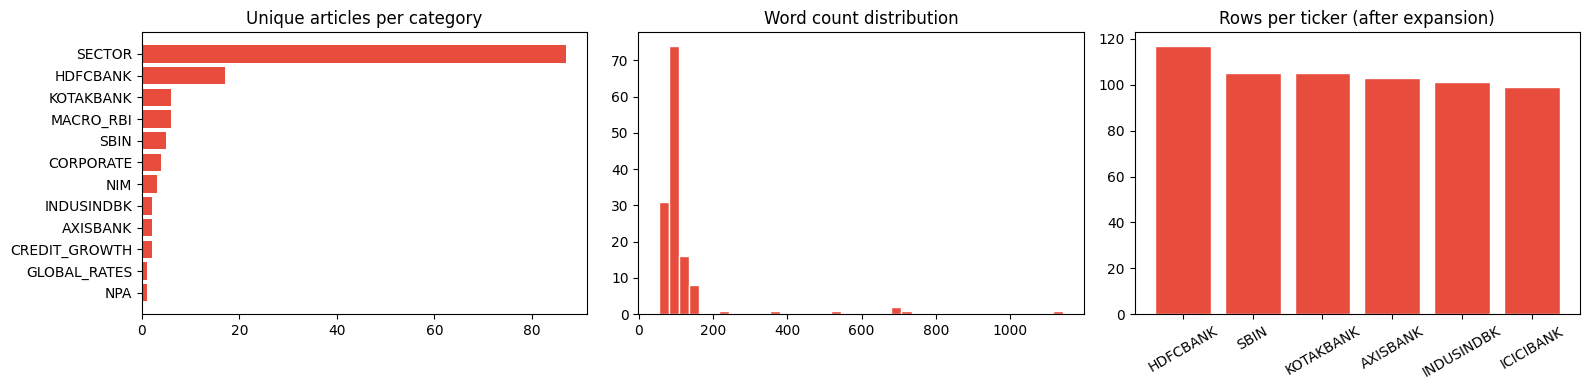


Sample headlines:
  [GLOBAL_RATES  ]  2024-09-18  "US Fed rate policy decision today: Check time, key details"
  [SECTOR        ]  2026-03-23  "Sula Vineyards promoter Rajeev Samant buys Rs 3-crore shares, raises stake "
  [SECTOR        ]  2026-03-09  "HDFC Bank, Axis Bank and more: 4 UPI credit cards that include features lik"
  [SECTOR        ]  2026-03-21  "Weekly Horoscope (23rd March - 29th March, 2026): Big Changes in Love, Fina"
  [KOTAKBANK     ]  2026-03-06  "SAT gives partial relief to Kotak AMC in Sebi case on fixed maturity plan p"
  [SECTOR        ]  2026-02-03  "RBI to start 3-day deliberations on interest rate from Wednesday"


In [11]:
import matplotlib.pyplot as plt

if len(et_df) == 0:
    print('No articles scraped yet. Check your URL list and re-run Section 7.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Articles per ticker
    tc = et_df.drop_duplicates('url')['category'].value_counts()
    axes[0].barh(tc.index, tc.values, color='#e74c3c')
    axes[0].set_title('Unique articles per category')
    axes[0].invert_yaxis()

    # Word count distribution
    axes[1].hist(et_df.drop_duplicates('url')['word_count'].clip(upper=2000),
                 bins=40, color='#e74c3c', edgecolor='white')
    axes[1].set_title('Word count distribution')

    # Ticker distribution
    tk = et_df['ticker'].value_counts()
    axes[2].bar(tk.index, tk.values, color='#e74c3c', edgecolor='white')
    axes[2].set_title('Rows per ticker (after expansion)')
    axes[2].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

    print('\nSample headlines:')
    for _, row in et_df.drop_duplicates('url').head(6).iterrows():
        print(f'  [{row["category"]:14s}]  {str(row["date"])[:10]}  "{row["headline"][:75]}"')

---
## 💾 Section 9 — Save

In [13]:
if len(et_df) > 0:
    # Full dataset
    et_df.to_csv(OUTPUT_CSV, index=False)
    print(f'Saved full dataset → {OUTPUT_CSV}  ({len(et_df)} rows)')

    # Slim version for main pipeline
    slim_path = OUTPUT_CSV.replace('.csv', '_slim.csv')
    et_df[['ticker', 'date', 'source', 'headline', 'text']].to_csv(slim_path, index=False)
    print(f'Saved slim dataset → {slim_path}')

    # Validation
    val = pd.read_csv(slim_path)
    val['date'] = pd.to_datetime(val['date'])
    print(f'\nValidation: shape={val.shape}')
    print(f'Tickers: {val["ticker"].unique()}')
    val.head(4)
else:
    print('Nothing to save — dataset is empty.')

Saved full dataset → et_banking_news.csv  (630 rows)
Saved slim dataset → et_banking_news_slim.csv

Validation: shape=(630, 5)
Tickers: <StringArray>
['HDFCBANK', 'ICICIBANK', 'SBIN', 'AXISBANK', 'KOTAKBANK', 'INDUSINDBK']
Length: 6, dtype: str


---
## 🔗 Section 10 — Combine with Guardian Data (Optional)

In [17]:
import os

guardian_slim = 'guardian_banking_news_slim.csv'
et_slim       = OUTPUT_CSV.replace('.csv', '_slim.csv')

frames = []
for path in [guardian_slim, et_slim]:
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['date'] = pd.to_datetime(df['date'])
        frames.append(df)
        print(f'Loaded {path}: {len(df)} rows')
    else:
        print(f'[SKIP] {path} not found')

if frames:
    combined = pd.concat(frames, ignore_index=True)
    combined = combined.drop_duplicates(subset=['headline', 'date', 'ticker'])
    combined = combined.sort_values(['ticker', 'date']).reset_index(drop=True)
    combined.to_csv('all_banking_news_slim.csv', index=False)
    print(f'\nCombined dataset: {combined.shape}')
    print(f'Saved → all_banking_news_slim.csv')
    print(f'\nRows per ticker:')
    print(combined['ticker'].value_counts())

[SKIP] guardian_banking_news_slim.csv not found
Loaded et_banking_news_slim.csv: 15 rows

Combined dataset: (15, 5)
Saved → all_banking_news_slim.csv

Rows per ticker:
ticker
AXISBANK      3
HDFCBANK      3
ICICIBANK     3
SBIN          3
KOTAKBANK     2
INDUSINDBK    1
Name: count, dtype: int64


---
## 🔌 Section 11 — Plug into Main Pipeline

In `banking_sentiment_analysis.ipynb`, replace the news collection cell with:

```python
# Load combined news (Guardian + Economic Times)
text_df = pd.read_csv('all_banking_news_slim.csv')
text_df['date'] = pd.to_datetime(text_df['date'])
print(f'Total news records: {len(text_df)}')
print(text_df['ticker'].value_counts())
```

---

## 💡 Tips for Getting More URLs from Economic Times

| Method | URL pattern |
|--------|-------------|
| Banking section | `https://economictimes.indiatimes.com/industry/banking/finance/banking` |
| Bank stocks news | `https://economictimes.indiatimes.com/markets/stocks/news` |
| Search for HDFC | `https://economictimes.indiatimes.com/topic/hdfc-bank` |
| Search for ICICI | `https://economictimes.indiatimes.com/topic/icici-bank` |
| Search for SBI   | `https://economictimes.indiatimes.com/topic/sbi` |
| RBI news         | `https://economictimes.indiatimes.com/topic/rbi` |

Open any of these pages, right-click → **Copy all article links** and paste them into `ET_URLS`.